# Create a wavelength lookup table for ODIN

In [1]:
import scipp as sc
import scippnexus as snx
from ess.reduce import unwrap
from ess.reduce.nexus.types import AnyRun, Position
from ess.odin.beamline import choppers

## Setting up the workflow

In [2]:
source_position = sc.vector([0, 0, 0], unit='m')
disk_choppers = choppers(source_position)

wf = unwrap.LookupTableWorkflow()
wf[unwrap.DiskChoppers[AnyRun]] = disk_choppers
wf[Position[snx.NXsource, AnyRun]] = source_position
wf[unwrap.NumberOfSimulatedNeutrons] = 200_000  # Increase this number for more reliable results
wf[unwrap.SimulationSeed] = 1234
wf[unwrap.LtotalRange[AnyRun, snx.NXdetector]] = sc.scalar(5.0, unit="m"), sc.scalar(65.0, unit="m")
wf[unwrap.DistanceResolution] = sc.scalar(0.1, unit="m")
wf[unwrap.TimeResolution] = sc.scalar(250.0, unit='us')

## Compute the table

In [3]:
table = wf.compute(unwrap.LookupTable[AnyRun, snx.NXdetector])
table.array

<scipp.DataArray>
Dimensions: Sizes[distance:604, event_time_offset:573, ]
Coordinates:
* distance                  float64              [m]  (distance)  [4.8, 4.9, ..., 65, 65.1]
* event_time_offset         float64            [µs]  (event_time_offset)  [0, 249.75, ..., 142607, 142857]
Data:
                            float64             [Å]  (distance, event_time_offset)  [0.102794, 0.158743, ..., 8.55148, 8.56883]  [0, 0.0020695, ..., 0.000247541, 6.35552e-05]

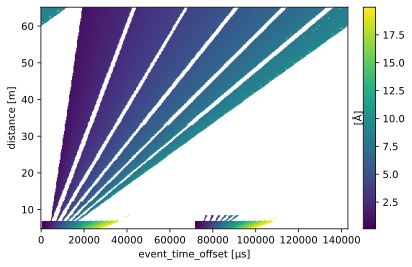

In [4]:
table.plot()

## Save to file

In [5]:
# Write to file
table.save_hdf5('ODIN-wavelength-lookup-table-5m-65m.h5')

Writing type '<class 'NoneType'>' to HDF5 not implemented, skipping.


Writing type '<class 'NoneType'>' to HDF5 not implemented, skipping.


Writing type '<class 'NoneType'>' to HDF5 not implemented, skipping.


Writing type '<class 'NoneType'>' to HDF5 not implemented, skipping.


Writing type '<class 'NoneType'>' to HDF5 not implemented, skipping.


...

Writing type '<class 'NoneType'>' to HDF5 not implemented, skipping.


Writing type '<class 'NoneType'>' to HDF5 not implemented, skipping.


Writing type '<class 'NoneType'>' to HDF5 not implemented, skipping.


Writing type '<class 'NoneType'>' to HDF5 not implemented, skipping.


Writing type '<class 'NoneType'>' to HDF5 not implemented, skipping.
